# CaF2 Control
### Cooldown 4
Really hope I can holeburn this time
* Confocal on GG4 with (110) CaF$_2$ unannealed in Mango
* Reflection on G4 with (111) CaF$_2$ (anneal status?)
* SNSPD1 on RR2

### Setup

In [1]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import math
import scipy as sp
import datetime
import scipy.fft
import scipy.optimize as sp
import os
import time
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa
from IPython.display import clear_output,display
import pyvisa
import TimeTagger
from windfreak import SynthHD

sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")
# Drivers
from unit_dmm.ut61eplus.ut61eplus import UT61EPLUS
from dlc_control.qil_DlcControl import dlccontrol as ctrl

# Helpers
import qil_helpers.Ben.LaserWrappers as ben
import qil_helpers.Fergus.magnet_helpers as ferg
import qil_helpers.Angela.sweeping as swp
import qil_helpers.Angela.switching as swtch
import qil_helpers.Angela.snspd as snshp
import qil_helpers.Angela.experimentHelpers as exhp
import qil_helpers.Tim.spectroscopyHelpers as sh
import qil_helpers.Tim.pulse_sequence as beeps
import qil_helpers.Tim.proHelpers as proHelp
import qil_helpers.Tim.laserHelpers as lhzz
import qil_helpers.Tim.plottingHelpers as plhp
import qil_helpers.Tim.plottingFunctions as plf

Laser didn't settle
Power/wavelength/frequency/offset is out of range, enter the correct value!
Laser is off, turn it on!
XE flag returned execution error
Importing Functions


In [3]:
### Toptica Laser
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
laserIP = '10.196.50.22'
timTam = ben.laser_TT(laserIP, 0.1)

### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter
try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host = 'qil-wario.research.sydney.edu.au')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

### Stahl power supply
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8            

### Moku AWG
import moku

### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

### For Bluey
import json 
import requests

# ### Keithley DMM
# import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
# dmm = dmm6500.Keithley_6500('dmm','TCPIP::10.196.50.27::INSTR')

### UNI-T dmm
unit = UT61EPLUS()

### Rigol oscilloscope 
from qil_Rigol.rigol import cRigol 
scope = cRigol('10.196.50.21') # IP address of Rigol MSO5104 on the gantry is: 10.196.50.21. verify connection here.

Importing Functions
Key error returned - wavemeter probably not seeing enough light.
Connected to: Stahl HV (serial:177, firmware:None) in 0.04s
Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 


In [42]:
### American magnetics power supply
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430
iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis
iz.add_parameter("get_vs", 
                 get_cmd ='VOLT:SUPP?', 
                 get_parser = float)
iz.add_parameter("get_cs", 
                 get_cmd ='CURR:SUPP?', 
                 get_parser = float) 

C:\Users\Mario\AppData\Local\Temp\ipykernel_9580\4276116187.py:3: QCoDeSDeprecationWarning: Use qcodes.instrument_drivers.american_magnetics.AMIModel430 instead.
  iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis


Connected to: AMERICAN MAGNETICS INC. 430 (serial:430-20-123, firmware:3.12) in 1.56s


<qcodes.parameters.parameter.Parameter: get_cs at 2800773916288>

In [18]:
### Attocube
import qil_attocube
amc = qil_attocube.Device('10.196.50.26')
amc.connect()

### Useful functions

In [82]:
# Various other functions
def getHistDataWrapped(hist, intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'lin'):
    data, times = getHistDataWrapped(intTime)
    laserFrequency = np.round(exhp.get_laser_frequency(wm, 20),6)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.title(str(laserFrequency) + ' THz, '+ str(intTime)+' s integration')              
    plt.legend()
#----------------------------------------------------------------------------#
def adjust_by_db(inputValue, gain):
    outputValue = inputValue * (10** (gain/10))

    return outputValue 
#----------------------------------------------------------------------------#
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)
#----------------------------------------------------------------------------#
def setfontsize(size, ax):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(size)
    return
#----------------------------------------------------------------------------#
def do_efficiency_measurement(measuredPower, windowTime, intTime, dutyCycle, gain):
    intTime = 2
    dutyCycle = 1
    windowTime = 0.1
    voltages = exhp.sweep_points(-0.75, -1.1, 0.005)
    biasCurrents = []
    totalCounts = []
    efficiencies = []

    power = measuredPower # measured in W

    frequency = exhp.get_laser_frequency(wm, 10)*1e12
    h = 6.626e-34
    ePerPhoton = h * frequency
    photonsPerSecond = power / ePerPhoton

    for i, voltage in enumerate(voltages):
        exhp.reset_detector(detectorOut, float(voltage))
        biasCurrents.append(exhp.get_detector_current(dmm))
        data, times = getHistDataWrapped(hist, intTime)
        totalCounts.append(sum(data))

        def countsToEffs(counts):
            countsPreOom = adjust_by_db(counts, gain) # 'amplifies' tt counts using OOM gain
            countsPerSecond = countsPreOom * windowTime/ (intTime * dutyCycle) # don't understand this line
            efficiency = 100*countsPerSecond/photonsPerSecond 
            return efficiency

        def effsToCounts(efficiency):
            countsPerSecond = efficiency*photonsPerSecond / 100
            countsPreOom=countsPerSecond* (intTime*dutyCycle) / windowTime
            counts = adjust_by_db(countsPreOom, -gain)
            return counts
        
        efficiencies.append(countsToEffs(sum(data)))
        numPhotons = adjust_by_db(photonsPerSecond, -gain)
        
        fig, ax = plt.subplots()
        fig.set_size_inches(cm2inch(20,12))
        ax.plot(biasCurrents, efficiencies)
        sec = ax.secondary_yaxis('right', functions=(effsToCounts, countsToEffs))

        ax.set_title("Efficiency vs i$_{bias}$, " +str(intTime)+"s Integration, "+str(round(numPhotons))+" Photons/s Exc")
        sec.set_ylabel("Counts")
        ax.set_ylabel('Efficiency (%)')
        # ax.set_ylim(0, 40)
        ax.set_xlabel("SSPD Bias Current ($\mu$A)")

        display(plt.gca())
        clear_output(wait=True)
        plt.show()
    
    exhp.reset_detector(detectorOut, -0.8)
    exhp.get_detector_current(dmm)

    fig, ax = plt.subplots()
    fig.set_size_inches(cm2inch(20,15))
    ax.plot(biasCurrents, efficiencies)
    sec = ax.secondary_yaxis('right', functions=(effsToCounts, countsToEffs))
    ax2 = ax.twiny()
    ax2.set_xlabel('Voltage (V)')
    ax2.plot(-voltages,efficiencies, 'C0')
    ax.set_title("Efficiency vs i$_{bias}$, " +str(intTime)+"s Integration, "+str(round(numPhotons))+" Photons/s Exc")
    sec.set_ylabel("Counts")
    ax.set_ylabel('Efficiency (%)')
    # ax.set_ylim(0, 40)
    ax.set_xlabel("SSPD Bias Current ($\mu$A)")

    display(plt.gca())
    clear_output(wait=True)
    plt.show()
    return (voltages, biasCurrents, totalCounts, efficiencies)   
#----------------------------------------------------------------------------#
def measure_dmm(dmm):
    meas = dmm.takeMeasurement()
    if not meas.overload:
        measurement  = meas.display
    else:
        measurement = -1
        print(f'WARNING: Check your sh*t')
    return measurement
#----------------------------------------------------------------------------#
def do_efficiency_measurement(detectorOut, unit, hist, wm, inputPower, countTimeRatio, voltageRange, voltageInt, runID, savePlot):
    ''' 
    Takes SNSPD efficiency measurement over bias current/voltage.

    ARGUMENTS (ignoring instruments)
    inputPower: optical power after attenuation
    countTimeRatio: ON/OFF time ratio for SNSPD trigger. depends on switching status
    voltageRange: [2x1 ARRAY] bias voltage range

    RETURNS 
    (voltages, biasCurrents, totalCounts, efficiencies), where length of each array depends on voltageRange and voltageInt
    '''

    intTime = 2
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    countsPerSecond = np.zeros_like(voltages)
    efficiencies = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    frequency = exhp.get_laser_frequency(wm, 1)*1e12 # Hz
    h = 6.62607015e-34
    ePerPhoton = h*frequency
    inputCounts = inputPower / ePerPhoton
    
    def normaliseCounts(measuredCounts, intTime, countTimeRatio):
        countsPerSecond =  measuredCounts / (intTime * countTimeRatio) 
        return countsPerSecond

    def countsToEffs(measuredCounts, intTime, countTimeRatio):
        countsPerSecond = normaliseCounts(measuredCounts, intTime, countTimeRatio) 
        efficiency = 100 * countsPerSecond / inputCounts 
        return efficiency
    
    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 1s before taking measurement
        biasCurrents[i] = exhp.get_detector_current(dmm) * 1e6 # store as uA
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s
        countsPerSecond[i] = normaliseCounts(totalCounts[i], intTime, countTimeRatio) # counts per second
        efficiencies[i] = countsToEffs(sum(data), intTime, countTimeRatio)

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, efficiencies)
        sec = ax.twinx()
        sec.plot(biasCurrents, countsPerSecond, alpha = 0)

        ax.set_title("Efficiency vs V$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
        ax.set_xlabel("- SNSPD Bias Voltage (V))")
        sec.set_ylabel("Counts")
        ax.set_ylabel('Efficiency (%)')
        # ax.set_ylim(0, 40)

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector once sweep is complete
    exhp.reset_detector(detectorOut, 0)
    measure_dmm(unit)

    # final plot
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(20, 15))
    ax.plot(voltages, efficiencies)
    sec = ax.twinx()
    sec.plot(voltages, countsPerSecond, alpha = 0)
    sec.set_ylabel(fr'Count Rate (s$^{-1}$)')
    ax2 = ax.twiny()
    ax2.set_xlabel('Voltage (V)')
    ax2.plot(biasCurrents, efficiencies, alpha = 0)
    ax.set_title("Efficiency vs i$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
    sec.set_ylabel(f"Total Counts in {intTime} s")
    ax.set_ylabel('Efficiency (%)')
    # ax.set_ylim(0, 40)
    ax.set_xlabel("SNSPD Bias Current ($\mu$A)")

    display(plt.gca())
    clear_output(wait = True)
    plt.tight_layout()
    if savePlot == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'plots/{dateString}'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return (voltages, biasCurrents, totalCounts, efficiencies)

def do_dark_measurement(detectorOut, dmm, hist, voltageRange, voltageInt, intTime, countTimeRatio, runID, save = False):
    '''
    Basically same measurement as above. But make sure the laser is shuttered/there is no input.
    '''
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 0.5s before taking measurement
        if dmm == unit:
            bias = measure_dmm(unit) # store as uA
        else:
            bias = exhp.get_detector_current(dmm)
        biasCurrents[i] = bias
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, totalCounts / (countTimeRatio * intTime), c = 'tab:blue')

        ax.set_title(fr"Dark Counts vs V$_{{bias}}$, " + str(intTime) + "s Integration")
        # ax.set_xlabel(r"SNSPD Bias Current ($\mu$A)")
        ax.set_xlabel(r"SNSPD Bias Voltage (V)")
        ax.set_ylabel(r"Dark Count Rate (s$^{-1}$)")

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector after measurement
    exhp.reset_detector(detectorOut, 0)
    time.sleep(1)
    if dmm == unit:
        measure_dmm(unit) # store as uA
    else:
        exhp.get_detector_current(dmm)    
    return (voltages, biasCurrents, totalCounts)

### Free Instruments

In [ ]:
swtch.all_on(awg)

In [ ]:
exhp.reset_detector(detectorOut, -0.8)

-0.8

In [34]:
exhp.reset_detector(detectorOut, 0)
# time.sleep(1)
exhp.reset_detector(detectorOut, -0.85)
# measure_dmm(unit)

-0.85

In [41]:
import TimeTagger
tt = TimeTagger.createTimeTagger()
TimeTagger.freeTimeTagger(tt)
tt

<TimeTagger.TimeTagger; proxy of None >

In [ ]:
stahl.close()
# dmm.close()
# iz.close()

In [36]:
lhzz.turn_laser_off(laserIP)

Laser is off


In [37]:
lhzz.is_laser_on(laserIP)

False

### Test Histogram

In [ ]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 500e-6, # s
    n_bins = 120
)

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 
binwidth = 120e-6 * ps  # s
n_bins = 500 # number of bins

tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

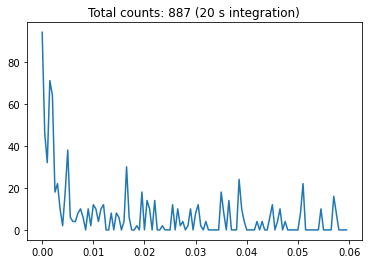

In [ ]:
# TEST HISTOGRAM
intTime = 20
exhp.reset_detector(detectorOut, -0.80)
counts, bins = getHistDataWrapped(hist, intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

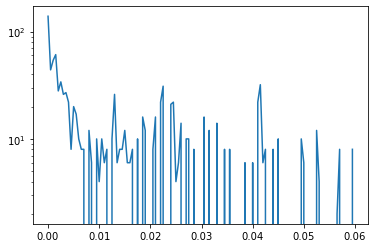

In [ ]:
plt.semilogy(bins, counts)
plt.show()

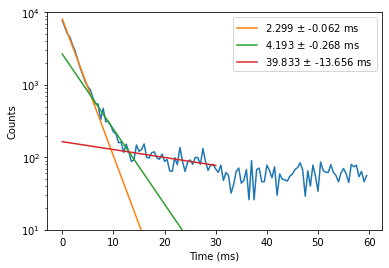

In [ ]:
# 140V piezo scan amplitude on annealed G1
plt.semilogy(bins*1e3, counts)
maskA = counts > 0
bins = bins[maskA]
counts = counts[maskA]
slopeA, interceptA, r, p, stderrA = stats.linregress(bins[0:10], np.log(counts)[0:10])
lifetimeA = -1/slopeA * 1e3
slopeB, interceptB, r, p, stderrB = stats.linregress(bins[10:30], np.log(counts)[10:30])
lifetimeB = -1/slopeB * 1e3
slopeC, interceptC, r, p, stderrC = stats.linregress(bins[30:60], np.log(counts)[30:60])
lifetimeC = -1/slopeC * 1e3

x = np.array([bins[0], bins[60]])
plt.semilogy(x * 1e3, np.exp(slopeA * x + interceptA), 
             label = fr'{lifetimeA:.3f} $\pm$ {lifetimeA * stderrA/slopeA :.3f} ms')
plt.semilogy(x * 1e3, np.exp(slopeB * x + interceptB), 
             label = fr'{lifetimeB:.3f} $\pm$ {lifetimeB * stderrB/slopeB :.3f} ms')
plt.semilogy(x * 1e3, np.exp(slopeC * x + interceptC), 
             label = fr'{lifetimeC:.3f} $\pm$ {lifetimeC * stderrC/slopeC :.3f} ms')
plt.semilogy()
plt.ylim([10, 10e3])
plt.xlabel('Time (ms)')
plt.ylabel('Counts')
plt.legend()
plt.show()

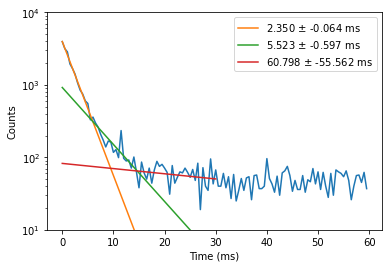

In [ ]:
# 0V piezo scan amplitude on annealed G1
plt.semilogy(bins*1e3, counts)
maskA = counts > 0
bins = bins[maskA]
counts = counts[maskA]
slopeA, interceptA, r, p, stderrA = stats.linregress(bins[0:10], np.log(counts)[0:10])
lifetimeA = -1/slopeA * 1e3
slopeB, interceptB, r, p, stderrB = stats.linregress(bins[10:30], np.log(counts)[10:30])
lifetimeB = -1/slopeB * 1e3
slopeC, interceptC, r, p, stderrC = stats.linregress(bins[30:60], np.log(counts)[30:60])
lifetimeC = -1/slopeC * 1e3

x = np.array([bins[0], bins[60]])
plt.semilogy(x * 1e3, np.exp(slopeA * x + interceptA), 
             label = fr'{lifetimeA:.3f} $\pm$ {lifetimeA * stderrA/slopeA :.3f} ms')
plt.semilogy(x * 1e3, np.exp(slopeB * x + interceptB), 
             label = fr'{lifetimeB:.3f} $\pm$ {lifetimeB * stderrB/slopeB :.3f} ms')
plt.semilogy(x * 1e3, np.exp(slopeC * x + interceptC), 
             label = fr'{lifetimeC:.3f} $\pm$ {lifetimeC * stderrC/slopeC :.3f} ms')
plt.semilogy()
plt.ylim([10, 10e3])
plt.xlabel('Time (ms)')
plt.ylabel('Counts')
plt.legend()
plt.show()

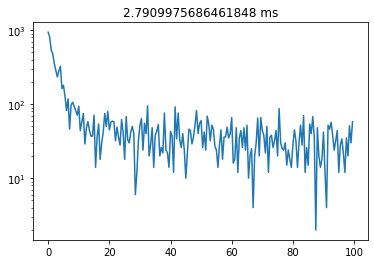

In [ ]:
# Off the annealed CaF line at 1507 nm
plt.semilogy(bins*1e3, counts)
maskA = counts > 0
bins = bins[maskA]
counts = counts[maskA]
slope, intercept, *_ = stats.linregress(bins[0:15], np.log(counts)[0:15])
lifetime = -1/slope * 1e3
plt.title(f'{lifetime} ms')
plt.show()

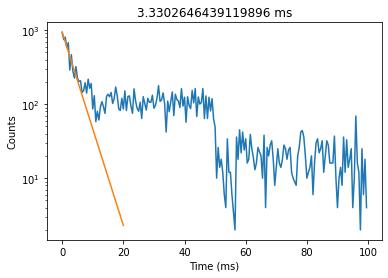

In [ ]:
# Reflection off PC fibre at 1507 nm
plt.semilogy(bins*1e3, counts)
maskA = counts > 0
bins = bins[maskA]
counts = counts[maskA]
slope, intercept, *_ = stats.linregress(bins[0:10], np.log(counts)[0:10])
lifetime = -1/slope * 1e3
plt.title(f'{lifetime} ms')
x = np.array([bins[0], bins[40]])
plt.semilogy(x * 1e3, np.exp(slope * x + intercept))
plt.xlabel('Time (ms)')
plt.ylabel('Counts')
plt.show()

# SNSPDs
## Efficiency vs. Bias

### 06/02
Efficiency measurement comparison: Tim vs. Angela code
#### Run 1
* Deadtime on clicks channel is 50 ns
#### Run 2 
* Deadtime on clicks channel is 25 ns
#### Run 3
* Deadtime on clicks channel is 15 ns
#### Run 4
* Deadtime on clicks channel is 5 ns
#### Run 5
* Deadtime on clicks channel is 2 ns, 0.045V trigger
#### Run 6
* 0.1 ns, 0.05V trigger
#### Run 7
* 0.1 ns, 0.042V trigger

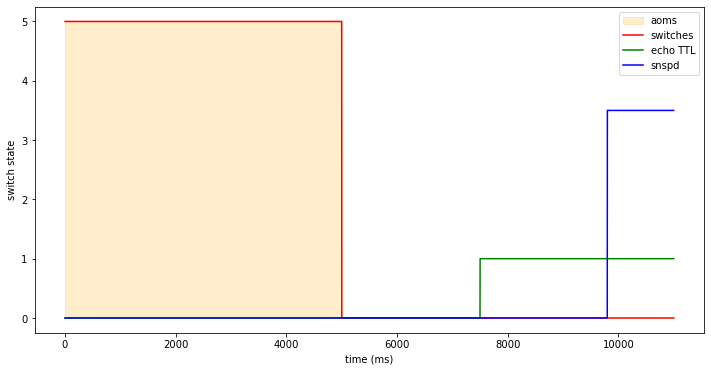

In [96]:
# import TimeTagger
# tt = TimeTagger.createTimeTagger()
# ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
# binwidth = 1e-6 * ps # 1 us, in picoseconds - [s] * [ps/s]
# n_bins = 100e3 # 10 000 bins for a total of 100 ms
# hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
# tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
# tt.setDeadtime(2, 0.01e-9*ps) # set 0.01 ns dead time
# tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV

swtch.set_up_echo_SNSPD(awg, 5000e3, 0, 0, countFor = 1000e3, switchPreDelay = 200e3, plotting  = True)
swtch.set_up_echo_SNSPD(awg, 5000e3, 0, 0, countFor = 1000e3, switchPreDelay = 200e3, plotting  = False)


In [342]:
# Set frequency to 197 THz 
lhzz.set_piezo_center(laserIP, 70)
lhzz.set_laser_wavelength(laserIP, 1521.660)
time.sleep(1)
ben.PIDtoSetpointToptica(timTam, wm, target = 197.000,
                         N = 5, Kp = 2, Ki = 2, Kd = 2, dt = 1)

Wavelength already set to 1521.66


[197.00137329101562,
 197.00099182128906,
 197.00071716308594,
 197.0003662109375,
 197.00003051757812]

In [356]:
runID = 1

In [385]:
# Set deadtime
# tt.setDeadtime(2, 0.01e-9*ps) # set 0.01 ns dead time
tt.setDeadtime(2, 10e-9*ps) # set 10 ns dead time

print(runID)

6


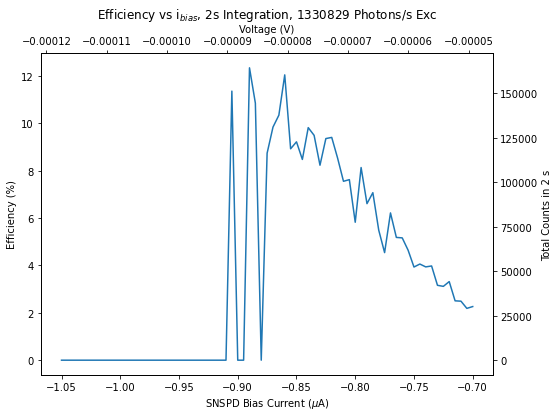

Laser is off


In [ ]:
print(fr'Run {runID}')
nameID = 'iz_on_10ns'
gain =  44.1 + 57.1

Angvoltages, AngbiasCurrents, AngtotalCounts, Angefficiencies = do_efficiency_measurement(detectorOut,
                                                                                            unit,
                                                                                            hist,
                                                                                            wm,
                                                                                            inputPower = (2.290e-3)*10**(-gain/10),
                                                                                            countTimeRatio = 200/600,
                                                                                            voltageRange = [-0.70, -1.05],
                                                                                            voltageInt = 0.005,
                                                                                            runID = runID,
                                                                                            savePlot = False)

In [387]:
dateString = time.strftime('%Y-%m-%d')
dataPath = fr"C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/{dateString}/efficiency"
os.makedirs(dataPath, exist_ok = True)

efficiencyData = np.column_stack((Angvoltages, AngbiasCurrents, AngtotalCounts, Angefficiencies))
name = os.path.join(dataPath, f'efficiency_{nameID}.csv')
np.savetxt(name, efficiencyData, delimiter = ',')

runID += 1

## DC Supply test
* Using normal switching setup for IH lines

In [133]:
def getHistDataWrapped(intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'lin'):
    data, times = getHistDataWrapped(intTime)
    laserFrequency = np.round(exhp.get_laser_frequency(wm, 20),6)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.title(str(laserFrequency) + ' THz, '+ str(intTime)+' s integration')              
    plt.legend()

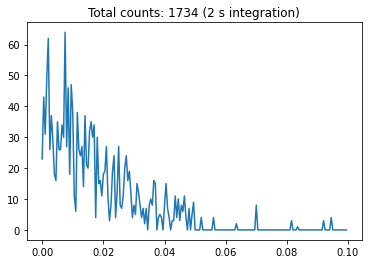

'-5.57'

In [136]:
# Test Histogram
intTime = 2
exhp.reset_detector(detectorOut, -0.82)
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()
measure_dmm(unit)

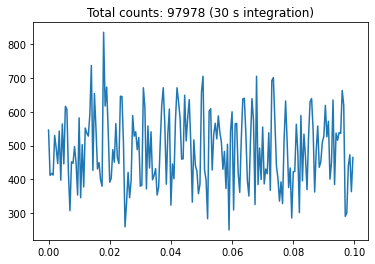

In [527]:
# Stahl dark counts at -5.3 uA bias on Keithley (MAINS)
exhp.reset_detector(detectorOut, -0.84)
intTime = 30
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

-5.250151000000001


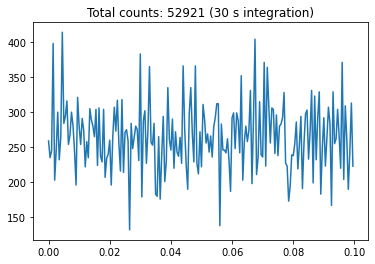

In [14]:
# Stahl dark counts at -5.3 uA bias on Keithley (UPS)
exhp.reset_detector(detectorOut, -0.84)
print(exhp.get_detector_current(dmm)*1e6)
intTime = 30
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

-5.232551


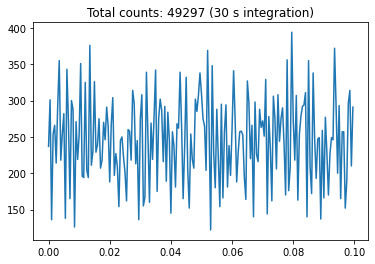

In [15]:
# Stahl dark counts at -5.3 uA bias on Keithley (UPS and z-axis controller)
exhp.reset_detector(detectorOut, -0.84)
print(exhp.get_detector_current(dmm)*1e6)
intTime = 30
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

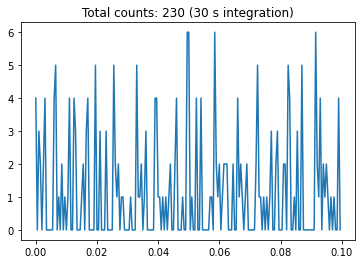

In [18]:
# Stahl dark counts at 5.3 uA bias on dmm (z-axis controller)
exhp.reset_detector(detectorOut, -0.84)
intTime = 30
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

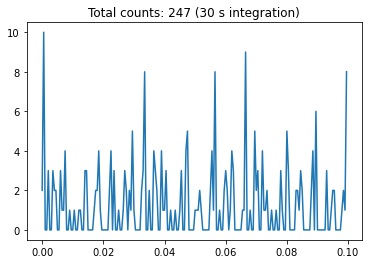

In [19]:
# Stahl dark counts at 5.3 uA bias on dmm (z-axis controller and PSU)
exhp.reset_detector(detectorOut, -0.84)
intTime = 30
counts, bins = getHistDataWrapped(intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

## Dark counts vs. Bias

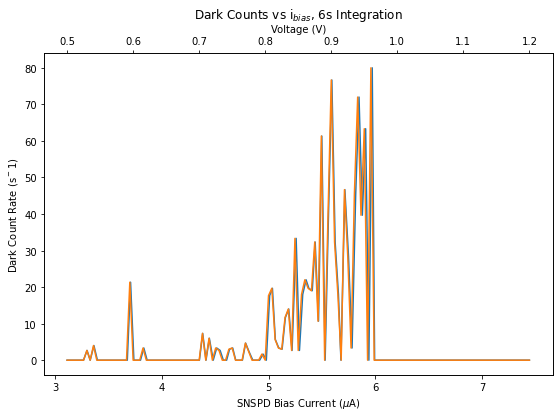

In [24]:
print(fr'Run {runID}')

# Time tagger
tt = TimeTagger.createTimeTagger()
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binwidth = 1e-6 * ps # 1 us, in picoseconds - [s] * [ps/s]
n_bins = 100e3 # 100 000 bins for a total of 100 ms
hist = TimeTagger.Histogram(tagger=tt, start_channel=2, click_channel=1, binwidth=binwidth, n_bins = n_bins)
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.045) # click channel trigger level = 45 mV

# Switchy
exhp.set_up_echo_SNSPD(awg, 50e3,0,0, countFor = 100e3, switchPreDelay = 200e3, plotting = True)
exhp.set_up_echo_SNSPD(awg, 50e3,0,0, countFor = 100e3, switchPreDelay = 200e3, plotting = False)
exhp.set_deadcycles(awg, 1, (1, 2, 3, 4))

# Experiment parameters
countTimeRatio = 200/400 # read off scope - duty cycle is 2
intTime = 6

# Run and plot
voltagesDark, biasCurrentsDark, totalCountsDark = snshp.do_dark_measurement(detectorOut,
                                                                            dmm,
                                                                            hist,
                                                                            voltageRange = [-0.5, -1.2],
                                                                            voltageInt = 0.005,
                                                                            intTime = intTime,
                                                                            countTimeRatio = countTimeRatio,
                                                                            runID = runID, 
                                                                            save = True)

# Save data
dateString = time.strftime('%Y-%m-%d')
dataPath = fr'data/{dateString}/dark'
os.makedirs(dataPath, exist_ok = True)

dark_data = {fr'Bias Voltage (V)': voltagesDark, 
              fr'Bia Current (mA)': biasCurrentsDark, 
              fr'Total Counts from {intTime}s Integration': totalCountsDark}
dark = pd.DataFrame(dark_data)
dark.to_csv(os.path.join(dataPath, fr'efficiency_run{runID}.csv'))

runID += 1

### 28/01
I am seeing 'burst' type of noise again. Ben's holeburning and Fergus's RF experiments are running with the z-axis PSU.

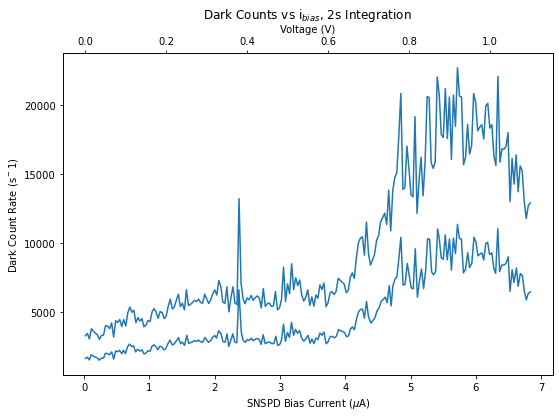

In [ ]:
# run 5 
voltagesDark5, biasCurrentsDark5, totalCountsDark5 = snshp.do_dark_measurement(countTimeRatio = 200/400)

# save data
dark5_data = {'Bias Voltage (V)': voltagesDark5, 
              'Bia Current (mA)': biasCurrentsDark5, 
              'Total Counts from 2s Integration': totalCountsDark5}
dark5 = pd.DataFrame(dark5_data)
dark5.to_csv('data/2026-01-28/dark counts/dark5.csv')

In [58]:
exhp.reset_detector(detectorOut, -0.82)
exhp.get_detector_current(dmm)*1e6

5.109327

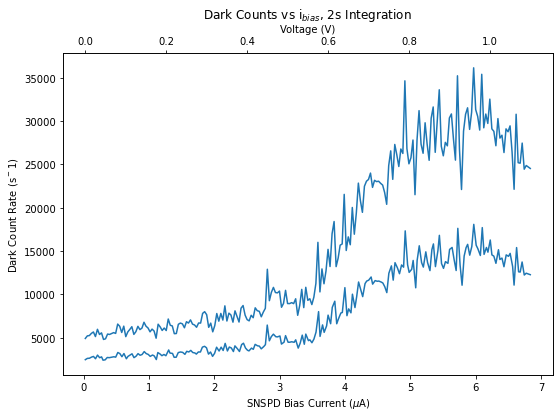

In [ ]:
# run 6 
# I have tightened SMAs in the circuit and the spikes have disappeared but there still seems to be DC noise 
# Okay I think it's just Ben's stray photons
voltagesDark6, biasCurrentsDark6, totalCountsDark6 = snshp.do_dark_measurement(countTimeRatio = 200/400)

# save data
dark6_data = {'Bias Voltage (V)': voltagesDark6, 
              'Bia Current (mA)': biasCurrentsDark6, 
              'Total Counts from 2s Integration': totalCountsDark6}
dark6 = pd.DataFrame(dark5_data)
dark6.to_csv('data/2026-01-28/dark counts/dark6.csv')

In [32]:
dark6 = pd.DataFrame(dark6_data)
dark6.to_csv('data/2026-01-28/dark counts/dark6.csv')

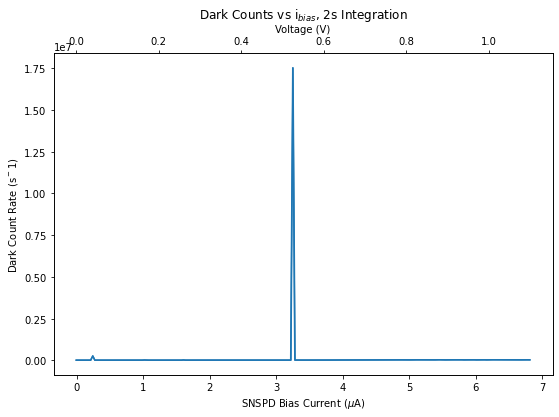

PermissionError: [Errno 13] Permission denied: 'data/2026-01-28/dark counts/dark6.csv'

In [ ]:
# run 7
# Checking if DC nois is higher power - Ben's stray photons?
voltagesDark7, biasCurrentsDark7, totalCountsDark7 = snshp.do_dark_measurement(countTimeRatio = 200/400)

# save data
dark7_data = {'Bias Voltage (V)': voltagesDark7, 
              'Bia Current (mA)': biasCurrentsDark7, 
              'Total Counts from 2s Integration': totalCountsDark7}
dark7 = pd.DataFrame(dark7_data)

In [31]:
dark7 = pd.DataFrame(dark7_data)
dark7.to_csv('data/2026-01-28/dark counts/dark7.csv')

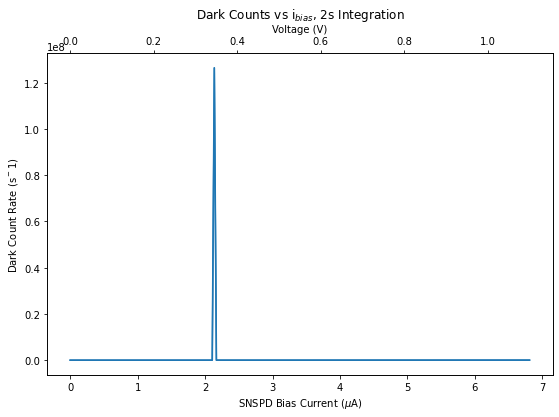

In [ ]:
# run 8
# Checking if DC nois is higher power - Ben's stray photons?
voltagesDark8, biasCurrentsDark8, totalCountsDark8 = snshp.do_dark_measurement(countTimeRatio = 200/400)

# save data
dark8_data = {'Bias Voltage (V)': voltagesDark8, 
              'Bia Current (mA)': biasCurrentsDark8, 
              'Total Counts from 2s Integration': totalCountsDark8}
dark8 = pd.DataFrame(dark8_data)

In [34]:
dark8 = pd.DataFrame(dark8_data)
dark8.to_csv('data/2026-01-28/dark counts/dark8.csv')

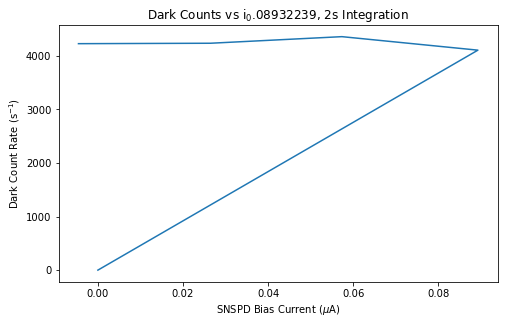

KeyboardInterrupt: 

In [ ]:
# run 9
# Checking if DC noise is higher power - Ben's experiment off
# YES IT IS HIGHER
voltagesDark9, biasCurrentsDark9, totalCountsDark9 = snshp.do_dark_measurement(countTimeRatio = 200/400)

# save data
dark9_data = {'Bias Voltage (V)': voltagesDark9, 
              'Bia Current (mA)': biasCurrentsDark9, 
              'Total Counts from 2s Integration': totalCountsDark9}
dark8 = pd.DataFrame(dark9_data)

### 02/02
I have introduced a 3dB attenuator between the amplifiers. Also noting that fridge temperatures, pressures, and flow rate are fluctuating - currently coldplate is sitting at 103.66 mK. The plan is to compare UPS (mains power) with only mains.
* Run 10 is on the UPS (mains)
* Run 11 is on mains

### 10/02
Tuning for dark count plots

* Runs on 11/02 are with y-axis PSU

In [319]:
runID = 1

In [414]:
# Set deadtime
# tt.setDeadtime(2, 0.01e-9*ps) # set 0.01 ns dead time
tt.setDeadtime(2, 10e-9*ps) # set 10 ns dead time

print(runID)

12


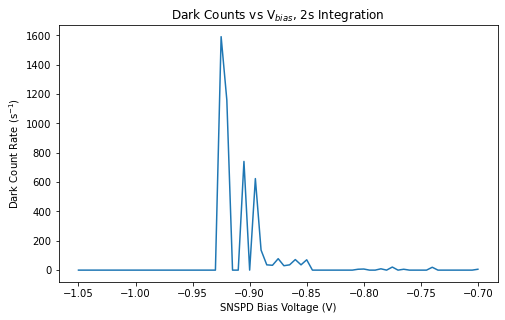

100%|██████████| 71/71 [04:22<00:00,  3.70s/it]


In [415]:
print(fr'Run {runID}')
nameID = 'iz_on_10ns'

# this runs and plots
voltagesDark, biasCurrentsDark, totalCountsDark = do_dark_measurement(detectorOut, dmm, hist, 
                                                                        voltageRange = [-0.7, -1.05],
                                                                        voltageInt = 0.005,
                                                                        intTime = 2,
                                                                        countTimeRatio = 200/600, 
                                                                        runID = runID, 
                                                                        save = False)

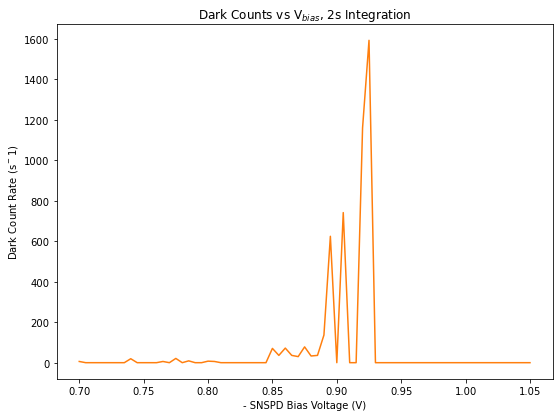

In [416]:
# final plot
fig, ax = plt.subplots()
fig.set_size_inches(plhp.cm2inch(20,15))
countTimeRatio = 200/600
intTime = 2

ax.set_xlabel('Voltage (V)')
ax.plot(-voltagesDark, totalCountsDark / (countTimeRatio * intTime), 'tab:orange')
ax.set_title("Dark Counts vs V$_{{bias}}$, " + str(intTime) + "s Integration")
ax.set_ylabel(fr'Dark Count Rate (s$^{-1}$)')
ax.set_xlabel(fr"- SNSPD Bias Voltage (V)")

plt.tight_layout()
plt.show()

# save data
dateString = time.strftime('%Y-%m-%d')
dataPath = fr"C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/{dateString}/dark"
os.makedirs(dataPath, exist_ok = True)

darkData = np.column_stack((voltagesDark, biasCurrentsDark, totalCountsDark))
name = os.path.join(dataPath, f'dark_{nameID}.csv')
np.savetxt(name, darkData, delimiter = ',')

runID += 1

# Inhomogeneous Lines
See effect of permanent magnet environment from Ben's setup on inhomogeneous lines?
* Feasibility of TBP for each line seems low..

*Run 3*
* Trigger is at 55 mV
* Timtam at 120 mA
* Motor step + piezo scan, no dither
* 380 MHz on AOMs

*Run 4*
* Trigger is at 45 mV
* Timtam at 120 mA
* Motor step + piezo scan, no dither
* 380 MHz on Aoms

*Run 5*
* Do a motor/piezo scan from 197000-199250 GHz in 0.4 GHz intervals with 20s integration

*Run 6*
* Rerun IH lines on A and G1 sites with shorter integration, more steps

In [8]:
# Default: [frequency (THz), wavelength (nm), label]
trn = {
    'A_Z1Y1': [197.049, 1521.305, r'A: $Z_1 \to Y_1$'],
    'G1_Z1Y1': [197.4686, 1518.071, r'G1: $Z_1 \to Y_1$'],
    'A_Z1Y2': [197.912, 1514.673, r'A: $Z_1 \to Y_2$'],
    'G1_Z1Y2': [198.2567, 1512.038, r'G1: $Z_1 \to Y_2$'],
    'B_Z1Y1': [198.76215, 1508.195, r'B: $Z_1 \to Y_1$'],
    'Cube_Z1Y1': [198.927, 1506.945, r'Cubic: $Z_1 \to Y_1$'],
    'Cube_Z1Y2':[199.242, 1504.563, r'Cubic: $Z_1 \to Y_2$']
    }

In [9]:
# SWEEP SETUP
# linesFreq = [
#          trn['A_Z1Y1'][0],
#          trn['G1_Z1Y1'][0],
#          ]
# linesLabel = [
#          trn['A_Z1Y1'][2],
#          trn['G1_Z1Y1'][2],
#          ]

# wavelengths = [1512.038, 1514.673, 1518.071, 1521.305]
# wavelengths = [1518.058, 1521.288]

sweep = swp.timTam_config(
    run_id = 'anneal caf',
    wavelengths = wavelengths,
    piezo_centre = 70,
    scan_half = 30,
    num_steps = 60,
    bias = -0.85,
    int_time = 55,
    laser_amplitude = 110,
)

print(fr"Set wavelengths: {wavelengths}")

Set wavelengths: [1506.89612725 1506.89708603 1506.89804481 1506.89900359 1506.89996238
 1506.90092116 1506.90187995 1506.90283874 1506.90379753 1506.90475632
 1506.90571511 1506.9066739  1506.90763269 1506.90859149 1506.90955028
 1506.91050908 1506.91146788 1506.91242668 1506.91338548 1506.91434428
 1506.91530309 1506.91626189 1506.9172207  1506.91817951 1506.91913831
 1506.92009712 1506.92105593 1506.92201475 1506.92297356 1506.92393237
 1506.92489119 1506.92585001 1506.92680882 1506.92776764 1506.92872646
 1506.92968529 1506.93064411 1506.93160293 1506.93256176 1506.93352059
 1506.93447941 1506.93543824 1506.93639707 1506.93735591 1506.93831474
 1506.93927357 1506.94023241 1506.94119124 1506.94215008 1506.94310892
 1506.94406776 1506.9450266  1506.94598544 1506.94694429 1506.94790313
 1506.94886198 1506.94982083 1506.95077968 1506.95173853 1506.95269738
 1506.95365623 1506.95461508 1506.95557394 1506.95653279 1506.95749165
 1506.95845051 1506.95940937 1506.96036823 1506.96132709 150

cycleTime: 123.0 ms


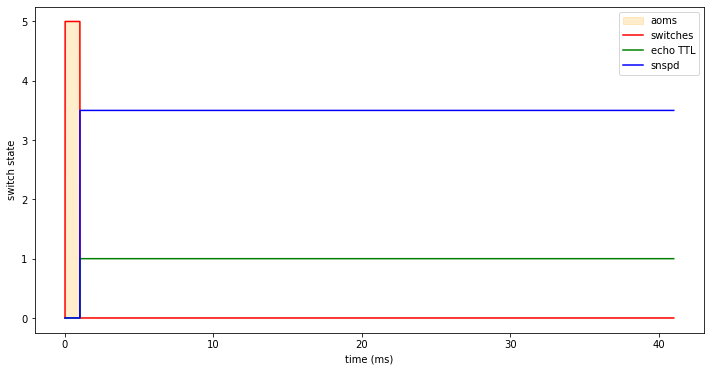

In [10]:
# SET UP AND APPLY SWITCHING PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 40e3, # us
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)
print(f'cycleTime: {((switch.exc_time + switch.count_time) * (switch.dead_cycle + 1))/1e3} ms')

In [12]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 400e-6, # s
    n_bins = 200
)

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 

tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width * ps, 
                             n_bins = tt_config.n_bins,
                             )

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, tt_config.dead_time * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, tt_config.trigger_level) # click channel trigger level = 42 mV

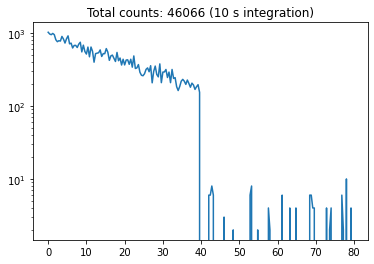

In [15]:
# TEST HISTOGRAM + TUNE INTEGRATION TIME
exhp.reset_detector(detectorOut, 0)
time.sleep(1)
exhp.reset_detector(detectorOut, -0.85)
time.sleep(1)

intTime = 10
counts, bins = getHistDataWrapped(hist, intTime = intTime)
plt.semilogy(bins * 1e3, counts, base = 10)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

In [48]:
# TEST FREQUENCIES
lhzz.set_piezo_center(laserIP, 70)

for wave in wavelengths:
    lhzz.set_laser_wavelength(laserIP, wave)
    time.sleep(5)
    print(fr'Measured frequency: {exhp.get_laser_frequency(wm, 10)} THz')

Wavelength now set to 1518.058
Measured frequency: 197.46934814453124 THz
Wavelength now set to 1521.288
Measured frequency: 197.05018310546876 THz


In [ ]:
# TEST AND TUNE BIAS FOR SNR - only valid for histogrammed data with half countTime, half deadTime
exhp.reset_detector(detectorOut, bias)

counts, bins = getHistDataWrapped(intTime = 2.2)
length = len(counts)
signal = np.sum(counts[0:math.floor(length/2)])
noise = np.sum(counts[math.ceil(length/2):length-1])
SNR = signal/noise

print(fr'SNR = {SNR:.3f}')
plt.plot(bins*1e3, counts)
plt.show()

In [90]:
def PLE_data_collect(
     description,
     sweep: swp.timTam_config,
     switch: swtch.PLE_switch_config,
     tt,
     aom_frequency, # GHz
     attocube,
     axis,
     magnet = None,
     extra_params = None,
     save_path = None):

    timestamp = datetime.datetime.now()
    timestring = timestamp.strftime("%Y-%m-%d_%H-%M-%S")

    data = {
        # Run information and ID
        "Description": description,
        "Run ID": sweep.run_id,
        "Timestamp": timestring,

        # Switch parameters
        "Excitation Time (ms)": switch.exc_time/1e3,
        "Count Time (ms)": switch.count_time/1e3,
        "Dead Cycle": switch.dead_cycle,
        "AOMs (GHz)": aom_frequency,

        # Measurement parameters
        "Dead Time (ps)": tt.dead_time,
        "Integration Time (s)": sweep.int_time,
        "Bin Width (us)": tt.bin_width*1e6,
        "Number of Bins": tt.n_bins,
        "Trigger Level (V)": tt.trigger_level,
        "Bias (V)": sweep.bias,

        # Laser sweep parameters
        "Laser Amplitude (mA)": sweep.laser_amplitude,
        "Piezo Centre (V)": sweep.piezo_centre,
        "Scan Half Range (V)": sweep.scan_half,
        "Num Steps": sweep.num_steps,
        "Wavelength centres (nm)": sweep.wavelengths,

        # Record attocube position
        "Attocube Position (nm)": float(attocube.control.getPositionsAndVoltages()[axis])
    }

    # Magnet
    if magnet is not None:
        data.update(AMI_data_collect(magnet, None))

    if extra_params is not None:
        data.update(extra_params)
    
    data_df = pd.DataFrame([data])
    data_df = data_df.T

    if save_path is None:
        save_path = r'C:\Users\Mario\Documents\GitHub\Angela Honours\experiment_log'
        os.makedirs(save_path, exist_ok = True)
        filename = f"{timestring}_{sweep.run_id}.csv"
        data_df.to_csv(os.path.join(save_path, filename), index = True)

    if save_path is not None:
        os.makedirs(save_path, exist_ok = True)
        filename = f"{timestring}_{sweep.run_id}.csv"
        data_df.to_csv(os.path.join(save_path, filename), index = True)
        
    return data_df

In [19]:
# SAVE METADATA
exhp.PLE_data_collect(
    description = 'caf_anneal_motor',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 0.410, 
    attocube = amc,
    axis = 0,
    save_path = r'C:\Users\Mario\Documents\GitHub\Angela Honours\experiment log'
)

,0
Description,caf_anneal_motor
Run ID,anneal caf
Timestamp,2026-05-04_17-36-14
Excitation Time (ms),1.0
Count Time (ms),40.0
Dead Cycle,2
AOMs (GHz),0.41
Dead Time (ps),0.0
Integration Time (s),55
Bin Width (us),400.0


In [20]:
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

sweepID = 1

### Piezo Scan by Sites

In [53]:
# MOTOR + PIEZO SCAN FOR FINE SCALE STRUCTURE
print(fr'Run {sweepID}')
lhzz.turn_laser_on(laserIP)

try:
    for i, wavelength in tqdm(enumerate(wavelengths), 
                              total = len(wavelengths),
                              desc = 'Wavelength centre...'):
        
        # SET LASER POWER? #
        lhzz.set_piezo_center(laserIP, sweep.piezo_centre) # Set piezo to centre
        lhzz.set_laser_wavelength(laserIP, wavelength) # Change motor centre

        # try:
        #     # PID TO LINE CENTRE 
        #     ben.PIDtoSetpointToptica(timTam, wm, target = linesFreq[i],
        #                     N = 16, Kp = 7, Ki = 3, Kd = 4, dt = 0.2)
        #     print('PID success!')

        # except Exception as e:
        #     print('PID failed... continuing anyways..')
        #     continue

        # SET PVs BASED ON LINE CENTRE
        centrepV = lhzz.get_piezo_center(laserIP)
        pVs = np.linspace(-sweep.scan_half, 
                        sweep.scan_half, 
                        sweep.num_steps) + centrepV
        
        # SUBFOLDER FOR EACH WAVLENGTH
        subFolderData = os.path.join(pathData, f"{wavelength:.5f}")
        subFolderPlots = os.path.join(pathPlots, f"{wavelength:.5f}")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)

        for j, pV in enumerate(pVs):
            lhzz.set_piezo_center(laserIP, pV)
            print(f"Starting step {j+1}, pV = {pV}")
            time.sleep(0.1)
            freq = exhp.get_laser_frequency(wm, 10)       # [THz]
            exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 0.01)
            data, times = exhp.getHistDataWrapped(hist, intTime = sweep.int_time)      
            dataAndTime = np.array([times, data])

            # save data
            now = datetime.datetime.now()
            filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_pV_" + str(np.round(pV, 1)) + "_V"
            np.savetxt(os.path.join(subFolderData, filename + ".csv"), 
                       dataAndTime, delimiter = ",")
            
            # plot data
            fig, ax = plt.subplots()
            ax.plot(times*1e3, data)
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
            ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
            fig.savefig(os.path.join(subFolderPlots, filename + ".png"))
            # fig.savefig(os.path.join(subFolderPlots, filename + ".eps"))
            plt.close(fig)
            clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)

sweepID += 1

Wavelength centre...: 100%|██████████| 2/2 [1:21:16<00:00, 2438.24s/it]


Laser is off


### Motor Scan

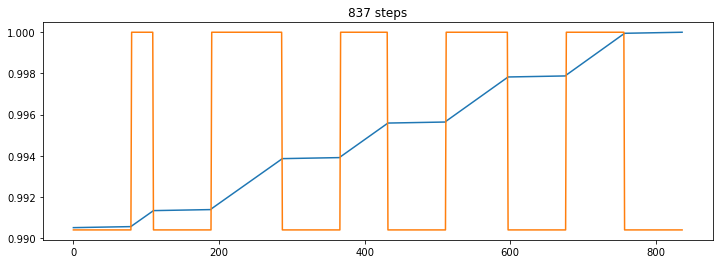

In [22]:
# Design wavelength array such that scale is finer around sites
c = 299792458
span = 20e9 # 20 GHz total span
num_points = 80 # resolution of each array
site_waves = {}
vacant_waves = {}
vacant_wavelengths = []

# freqs = {
#     "cube_z1y1": 198.928e12,
#     "b_z1y1": 198.762e12,
#     "g1_z1y2": 198.257e12,
#     "a_z1y2": 197.912e12,
#     "g1_z1y1": 197.469e12,
#     "a_z1y1": 197.049e12
# }

waves = {
    "cube_z1y1": 1506.934,
    "b_z1y1": 1508.192,
    "g1_z1y2": 1512.033,
    "a_z1y2": 1514.661,
    "g1_z1y1": 1518.066,
    "a_z1y1": 1521.294
}

freqs = {key: c / (w * 1e-9) for key, w in waves.items()}
sorted_sites = sorted(freqs.items(), key=lambda x: x[1])

# fine-scale scan around sites (0.25 GHz)
span = 10e9 # site span
for key, f0 in freqs.items():
    f_array = np.linspace(f0 - span/2, f0 + span/2, num_points)
    wave_array = c / f_array
    site_waves[key] = wave_array
site_cc = np.concatenate(list(site_waves.values()))

# broad scan elsewhere (10 GHz)
vacant_step = 5e9
for i in range(len(sorted_sites) - 1):
    key_low, freq_low = sorted_sites[i]
    freq_low_max = freq_low + span
    key_high, freq_high = sorted_sites[i + 1]
    freq_high_min = freq_high - span
    vacant_freq = np.arange(freq_low_max, freq_high_min, vacant_step)
    vacant_wavelengths.append(c / vacant_freq)
vacant_cc = np.concatenate(vacant_wavelengths)

# concatenate and plot
wavelengths = np.concatenate([site_cc, vacant_cc])
wavelengths = np.sort(wavelengths * 1e9)

idx = np.arange(0, len(wavelengths), 1)
plt.figure(figsize = (12, 4))
plt.plot(idx, wavelengths/max(wavelengths))
plt.title(fr'{len(wavelengths)} steps')

# amplitude array based on sites 
site_cc_nm = site_cc * 1e9
tol = 1e-6
amplitudes = np.zeros_like(wavelengths)

for i, wave in enumerate(wavelengths):
    match = np.any(np.isclose(wave, site_cc_nm, atol = tol))
    if match:
        amplitudes[i] = 0.4
    else:
        amplitudes[i] = 10
plt.plot(idx, amplitudes * 0.001  + 0.990)

# # to check range for piezo scan
# site_intervals = []
# for f0 in freqs.values():
#     f_min = f0 - span/2
#     f_max = f0 + span/2
#     site_intervals.append((f_min, f_max))

# # check logic for setting scan amplitude scan based on set wavelength
# truth = np.zeros(len(wavelengths))
# for i, wavelength in enumerate(wavelengths):
#     f = c / (wavelength * 1e-9)
#     in_site = any(f_min <= f <= f_max for (f_min, f_max) in site_intervals)
#     if in_site:
#         truth[i] = 1
#     else:
#         truth[i] = 0

# plt.plot(idx, truth * (np.max(wavelengths) - np.min(wavelengths)) + np.min(wavelengths), c = 'tab:red')
plt.show()

In [28]:
for key in waves:
    print(waves[key])

1506.934
1508.192
1512.033
1514.661
1518.066
1521.294


In [32]:
for key in waves:
    lhzz.set_laser_wavelength(laserIP, waves[key])
    time.sleep(5)
    print(f'Set Site: {key}')
    print(f'Measured Frequency: {exhp.get_laser_frequency(wm, 10)} GHz')
    

Wavelength now set to 1506.934
Set Site: cube_z1y1
Measured Frequency: 198.92866973876954 GHz
Wavelength now set to 1508.192
Set Site: b_z1y1
Measured Frequency: 198.76292724609374 GHz
Wavelength now set to 1512.033
Set Site: g1_z1y2
Measured Frequency: 198.2579147338867 GHz
Wavelength now set to 1514.661
Set Site: a_z1y2
Measured Frequency: 197.91354675292968 GHz
Wavelength now set to 1518.066
Set Site: g1_z1y1
Measured Frequency: 197.4697280883789 GHz
Wavelength now set to 1521.294
Set Site: a_z1y1
Measured Frequency: 197.05059051513672 GHz


In [5]:
sample = 'caf annealed'
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}\{sample}\motor'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}\{sample}\motor'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

sweepID = 1

In [ ]:
# MOTOR SCAN FOR LARGE SCALE STRUCTURE
lhzz.turn_laser_on(laserIP)
print(fr'Run {sweepID}')

# Savepath
subFolderData = pathData + "/" + f"run{sweepID}" + "/" # don't forget ending "/"
subFolderPlots = pathPlots + "/" + f"run{sweepID}" + "/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Measurement Parameters
intTime = sweep.int_time
bias = sweep.bias

try:
    for i, wavelength in tqdm(enumerate(wavelengths)):
        # set up measurement parameters
        lhzz.set_piezo_center(laserIP, 70)
        lhzz.set_laser_wavelength(laserIP, wavelength)
        lhzz.set_piezo_amplitude(laserIP, amplitudes[i])
        print(f'In site? {amplitudes[i] < 1}')
        time.sleep(0.1)
        exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
        time.sleep(0.7)
        freq = exhp.get_laser_frequency(wm, 10) # THz
        tqdm.write(f"Wavemeter at {freq:.3f} THz")

        # # set scan amplitude scan based on set wavelength
        # f = c / (wavelength * 1e-9)
        # in_site = any(f_min <= f <= f_max for (f_min, f_max) in site_intervals)
        # print(fr'In site? {in_site}')
        
        # if in_site: # small scan range in site
        #     lhzz.set_piezo_amplitude(laserIP, 0.4)
        # else: # large scan range outside site
        #     lhzz.set_piezo_amplitude(laserIP, 10)
        # time.sleep(0.1)
        # print(fr'{Piezo-voltage: lhzz.get_piezo_amplitude(laserIP)} V')

        # start sweep
        data, times = getHistDataWrapped(hist, intTime = intTime)      
        dataAndTime = np.array([times, data])
        exhp.reset_detector(detectorOut, 0, sleepTime = 0.1)

        # save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz"
        np.savetxt(subFolderData + filename + ".csv", dataAndTime, delimiter = ",")

        # plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({int} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".jpg")
        # fig.savefig(subFolderPlots + filename + ".eps")
        plt.close(fig)

        clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    sweepID += 1

306it [4:52:46, 57.41s/it]

Wavelength now set to 1512.0132110422019
In site? True


306it [4:52:49, 57.41s/it]

Wavemeter at 198.259 THz


# Attocube optimisation
* PLE off A Z1 -> Y2 as a function of position
* use 120 mA on toptica

### After that
* optimise for polarisation
* figure out PID issue
* magnet ramp parameters

In [25]:
# ATTOCUBE
controlFreq = 1000 # Hz
controlVoltage = 20 # V

amc.control.setControlFrequency(0, controlFreq * 1e3) # mHz
amc.control.setControlAmplitude(0, controlVoltage * 1e3) # mV

print(fr'Axis 1 at {amc.control.getControlAmplitude(0) / 1e3} V, {amc.control.getControlFrequency(0) / 1e3} Hz')

Axis 1 at 20.001 V, 999.982 Hz


In [27]:
# 3000 steps forward ~ 3500 steps backward
print(f'Start position: {amc.move.getPosition(0)} nm = {amc.move.getPosition(0)/1e3} um')
amc.move.setNSteps(axis = 0, backward = True, step = 2000)
time.sleep(10)
print(f'End position: {amc.move.getPosition(0)} nm = {amc.move.getPosition(0)/1e3} um')

Start position: 3686172.77 nm = 3686.17277 um
End position: 3811895.129 nm = 3811.895129 um


In [68]:
print(f'Position now: {amc.move.getPosition(0)} nm = {amc.move.getPosition(0)/1e3} um')

Position now: 3651944.723 nm = 3651.944723 um


In [ ]:
# Set frequency to A site Z1->Y2
lhzz.set_piezo_center(laserIP, piezoCentre)
lhzz.set_laser_wavelength(laserIP, 1514.658)
time.sleep(5)
print(exhp.get_laser_frequency(wm, 10))
ben.PIDtoSetpointToptica(timTam, wm ,
                         target = 197.913,
                         N = 10,
                         dt = 1)

Wavelength now set to 1514.658
197.9139602661133


[197.91183471679688,
 197.91358947753906,
 197.91363525390625,
 197.9156036376953,
 197.91067504882812,
 197.9137725830078,
 197.91270446777344,
 197.91287231445312,
 197.9127960205078,
 197.9127960205078]

In [73]:
stepSize = 800
steps = np.arange(0, 15000, stepSize)
waitTime = 1
axis = 0
numBins = 100
bias = -0.85

In [74]:
stepVsCounts = np.zeros([len(steps), 3]) # Initialise data storage for N trials [# steps, position, counts]
stepVsCounts[:, 0] = steps

# plt.ion()  # interactive mode on
# fig_live, ax_live = plt.subplots()
# line_live, = ax_live.plot([], [], 'o-', color='tab:red')
# ax_live.set_xlabel('Step index')
# ax_live.set_ylabel('Counts')

for i in tqdm(range(len(steps)), desc = 'Buzzing and counting...'):
    # Set SNSPD to 0 
    exhp.reset_detector(detectorOut, 0)

    # numSteps in forward direction and wait for T1
    amc.move.setNSteps(axis = 0, backward = False, step = stepSize)
    time.sleep(waitTime)

    # Start SNSPD and integrate for 2s
    exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
    data, times = exhp.getHistDataWrapped(hist, intTime = 5)
    
    # (Ideally) measure drift over time interval and take mean but measure single position point for now
    positionAfter = amc.move.getPosition(axis)
    stepVsCounts[i, 1] = positionAfter      
    counts = np.sum(data[0:numBins])
    stepVsCounts[i, 2] = counts

    # Live position
    print(f'Position now: {amc.move.getPosition(axis)/1e3} um')
    # line_live.set_data(
    #     np.arange(i+1),
    #     stepVsCounts[:i+1, 2])
    # ax_live.relim()
    # ax_live.autoscale_view()
    # plt.pause(0.01)
    
# plt.ioff()
# plt.show()

steps = stepVsCounts[:, 0]
position = stepVsCounts[:, 1]
counts = stepVsCounts[:, 2]

Buzzing and counting...:   5%|▌         | 1/19 [00:06<02:01,  6.74s/it]

Position now: 3933.5481860000004 um


Buzzing and counting...:  11%|█         | 2/19 [00:13<01:54,  6.73s/it]

Position now: 3944.033555 um


Buzzing and counting...:  16%|█▌        | 3/19 [00:20<01:47,  6.74s/it]

...

Position now: 3595.180799 um


Buzzing and counting...:  95%|█████████▍| 18/19 [02:01<00:06,  6.72s/it]

Position now: 3564.822635 um


Buzzing and counting...: 100%|██████████| 19/19 [02:07<00:00,  6.73s/it]

Position now: 3522.417036 um


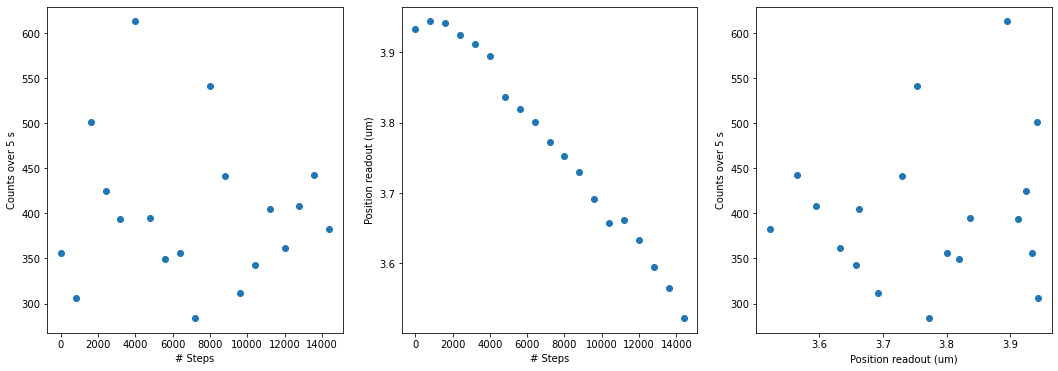

In [75]:
fig = plt.figure(figsize = (18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.scatter(steps, counts)
ax1.set_xlabel('# Steps')
ax1.set_ylabel(f'Counts over {5} s')

ax2.scatter(steps, position*1e-6)
ax2.set_xlabel('# Steps')
ax2.set_ylabel('Position readout (um)')

ax3.scatter(position*1e-6, counts)
ax3.set_xlabel('Position readout (um)')
ax3.set_ylabel(f'Counts over {5} s')

plt.show()

# peak = []
# peak.append(float(position[np.where(counts == np.max(counts))]))
# peak

# Magnet Ramp
### FIELD RAMP PLEASE

In [135]:
# Default: [frequency (THz), wavelength (nm), label]
# trn = {
#     'A_Z1Y1': [197.05, 1521.296, r'A: $Z_1 \to Y_1$'],
#     'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$'],
#     'A_Z1Y2': [197.913, 1514.664, r'A: $Z_1 \to Y_2$'],
#     'G1_Z1Y2': [198.2567, 1512.037, r'G1: $Z_1 \to Y_2$'],
#     'B_Z1Y1': [198.76215, 1508.195, r'B: $Z_1 \to Y_1$'],
#     'Cube_Z1Y1': [198.927, 1506.945, r'Cubic: $Z_1 \to Y_1$'],
#     'Cube_Z1Y2':[199.242, 1504.563, r'Cubic: $Z_1 \to Y_2$']
#     }

waves = {
    "g1_z1y2": 1512.028,
    "g1_z1y1": 1518.061,
}

wavelengths = [waves[key] for key in waves]

# linesFreq = []
# wavelengths = []
# lineslabel = []

# # FREQUENCY SWEEP SETUP
# for s, site in enumerate(trn):
#     site = list(trn.values())[s]
#     linesFreq.append(site[0])
#     wavelengths.append(site[1])
#     linesLabel.append(site[2])

# print(fr"Set wavelengths: {wavelengths} at {linesFreq} THz {linesLabel}")

In [147]:
sweep = swp.timTam_config(
    run_id = 'G1_SITE_MAGNET_RAMP_MANGO',
    wavelengths = wavelengths,
    piezo_centre = 70,
    scan_half = 70,
    num_steps = 64,
    bias = -0.85, 
    int_time = 5,
    laser_amplitude = 110, # CHECK ON TIMTAM
)

# FIELD SWEEP - FIND WAY TO STORE SWEEP PARAMETERS
iz.current_limit(7.2) # CHECK
print(iz.ramp_rate())
# iz.ramp_rate(0.5)
iz.coil_constant(1) # set cc = 1 
flds = ferg.define_target_fields(
    min_fld = 0, 
    max_fld = 7, 
    step = 55
)

0.1
Magnet Target Field Steps
Max Field = 7 T
Min Field = 0 T
Step Size = 0.12727272727272726 T
Number of Steps = 56

Field Array: [0.         0.12727273 0.25454545 0.38181818 0.50909091 0.63636364
 0.76363636 0.89090909 1.01818182 1.14545455 1.27272727 1.4
 1.52727273 1.65454545 1.78181818 1.90909091 2.03636364 2.16363636
 2.29090909 2.41818182 2.54545455 2.67272727 2.8        2.92727273
 3.05454545 3.18181818 3.30909091 3.43636364 3.56363636 3.69090909
 3.81818182 3.94545455 4.07272727 4.2        4.32727273 4.45454545
 4.58181818 4.70909091 4.83636364 4.96363636 5.09090909 5.21818182
 5.34545455 5.47272727 5.6        5.72727273 5.85454545 5.98181818
 6.10909091 6.23636364 6.36363636 6.49090909 6.61818182 6.74545455
 6.87272727 7.        ]

Reverse Field Array: [7.         6.87272727 6.74545455 6.61818182 6.49090909 6.36363636
 6.23636364 6.10909091 5.98181818 5.85454545 5.72727273 5.6
 5.47272727 5.34545455 5.21818182 5.09090909 4.96363636 4.83636364
 4.70909091 4.58181818 4.45454545

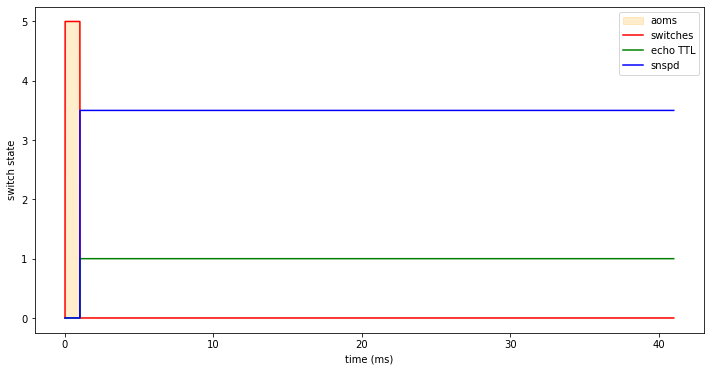

In [137]:
# SET UP AND APPLY SWITCHING PARAMETERS
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # s
    count_time = 40e3, # s
    dead_cycle = 2
)

swtch.PLE_switch_config.apply(switch, awg, test = False)

In [54]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 400e-6, # s
    n_bins = 200
)

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 
tt = TimeTagger.createTimeTagger()
binwidth = 400e-6 * ps  # s
n_bins = 200 # number of bins
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = binwidth, 
                             n_bins = n_bins)

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV

In [52]:
# TEST DETECTOR
lhzz.turn_laser_on(laserIP)
exhp.reset_detector(detectorOut, 0)

Laser is on


0

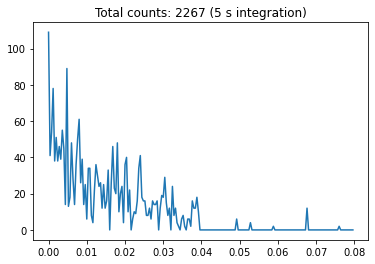

In [122]:
# TEST HISTOGRAM
intTime = sweep.int_time
exhp.reset_detector(detectorOut, -0.85)
counts, bins = getHistDataWrapped(hist, intTime = intTime)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

In [148]:
# SAVE SWEEP METADATA
PLE_data_collect(
    description = 'G1_SITE_MAGNET_RAMP_MANGO',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 0.410, 
    attocube = amc,
    axis = 0,
    save_path = r"C:\Users\Mario\Documents\GitHub\Angela Honours\experiment log")

,0
Description,G1_SITE_MAGNET_RAMP_MANGO
Run ID,G1_SITE_MAGNET_RAMP_MANGO
Timestamp,2026-05-05_18-37-31
Excitation Time (ms),1.0
Count Time (ms),40.0
Dead Cycle,2
AOMs (GHz),0.41
Dead Time (ps),0.0
Integration Time (s),5
Bin Width (us),400.0


In [139]:
# RUN ID BLOCK ONCE
magnetID = 1

In [104]:
# TUNE LASER CENTRE
lhzz.turn_laser_on(laserIP)
time.sleep(1)
lhzz.set_piezo_center(laserIP, 70)
lhzz.set_laser_wavelength(laserIP, trn['Cube_Z1Y1'][1]) # Change motor centre
exhp.get_laser_frequency(wm, 10)

# PID TO LASER CENTRE
ben.PIDtoSetpointToptica(timTam, wm, target = linesFreq[0],
                N = 10, Kp = 1e-2, Ki = 5e-3, Kd = 0, dt = 0.2)

Laser is on
Wavelength already set to 1506.945


[198.9245147705078,
 198.9239959716797,
 198.9233856201172,
 198.92271423339844,
 198.9219207763672,
 198.92103576660156,
 198.9200897216797,
 198.9189910888672,
 198.91783142089844,
 198.9165496826172]

In [140]:
lhzz.turn_laser_on(laserIP)
lhzz.set_piezo_center(laserIP, 70)
time.sleep(1)

for j in range(len(trn)):
    site = list(trn.values())[j] # freq, wavelength, label
    lhzz.set_laser_wavelength(laserIP, site[1])
    time.sleep(2)
    print(exhp.get_laser_frequency(wm, 10))

Laser is on
Wavelength now set to 1521.296
197.04452667236328
Wavelength now set to 1518.07
197.47013244628906
Wavelength now set to 1514.664
197.91426696777344
Wavelength now set to 1512.037
198.25831298828126
Wavelength now set to 1508.195
198.76339263916014
Wavelength now set to 1506.945
198.92820434570314
Wavelength now set to 1504.563
199.24327392578124


In [153]:
# CHECK MAGNET  
ferg.AMIcheck_up(iz)

State of <AMI430: z>:
Current limit:  7.2
Current Ramp limit:  3.6
Coil Constant:  1.0


Current:  7.00024704
Calculated Supply current:  6.999986216
Supply Voltage:  0.263096
Calculated System Resistance:  0.037585952872013204
Calculated Field: 6.999736818


In [72]:
# RAMP UP TO HIGH FIELD
magnet_data = []

for fld in flds:
    ferg.ramp_to_field(iz, fld)
    df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log")
    magnet_data.append(df)
    time.sleep(10)

##########RAMPING###########
RAMPING FIELD TO:  5.0  T
At 5.0 T. PSU State:
##########STATE check 1 ###########
State of <AMI430: z>:
Current limit:  7.2
Current Ramp limit:  3.6
Coil Constant:  1.0


Current:  5.00036248
Calculated Supply current:  5.000668997
Supply Voltage:  0.216088
Calculated System Resistance:  0.04320318486594457
Calculated Field: 5.001573303


Saved Magnet Data to C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log\magnet_data_2026-05-05
##########RAMPING###########
RAMPING FIELD TO:  5.1  T
At 5.1 T. PSU State:
##########STATE check 1 ###########
State of <AMI430: z>:
Current limit:  7.2
Current Ramp limit:  3.6
Coil Constant:  1.0


Current:  5.09625897
Calculated Supply current:  5.096622592
Supply Voltage:  0.219976
Calculated System Resistance:  0.04316716542374283
Calculated Field: 5.095840129


Saved Magnet Data to C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log\magnet_data_2026-05-05
##########RAMPING###########
RAMPI

In [142]:
datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\{datestring}\caf annealed'
pathPlots = fr'C:\Users\Mario\Documents\GitHub\Angela Honours\plots raw\{datestring}\caf annealed'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

magnetID = 1

In [149]:
# SCAN FIELD AND SWEEP FREQUENCY
print(fr'Run {magnetID}')
lhzz.turn_laser_on(laserIP)

try:
    for i, fld in tqdm(enumerate(flds[:: -1]), total = len(flds)):
    # RAMP DOWN TO 0 FIELD
        try:
            ferg.ramp_to_field(iz, fld)
        except Exception as e:
            print(fr"Magnet ramp failed at {fld}T")
            break

        # WAIT AND LOG MAGNET DATA
        time.sleep(0.1)
        df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\Angela Honours\experiment log")
            
        # SUBFOLDER FOR EACH FIELD
        subFolderData = os.path.join(pathData, f"run {magnetID}")
        subSubFolderData = os.path.join(subFolderData, f"{fld:.3f}A")
        subFolderPlots = os.path.join(pathPlots, f"run {magnetID}")
        subSubFolderPlots = os.path.join(subFolderPlots, f"{fld:.3f}A")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)
        os.makedirs(subSubFolderData, exist_ok = True)
        os.makedirs(subSubFolderPlots, exist_ok = True)
        
        for j, wave in enumerate(wavelengths):
            # SUBSUBFOLDER FOR EACH SITE
            subSubSubFolderData = os.path.join(subSubFolderData, f"{wave:.3f}")
            subSubSubFolderPlots = os.path.join(subSubFolderPlots, f"{wave:.3f}")
            os.makedirs(subSubSubFolderData, exist_ok = True)
            os.makedirs(subSubSubFolderPlots, exist_ok = True)

            # TUNE LASER CENTRE
            lhzz.set_piezo_center(laserIP, 70) # Set piezo to centre
            lhzz.set_laser_wavelength(laserIP, wave) # Change motor centre

            # # DON'T BOTHER PID IF DITHERING
            # # PID TO LINE CENTRE 
            # try:
            #     ben.PIDtoSetpointToptica(timTam, wm, target = linesFreq[j],
            #                     N = 10, Kp = 2, Ki = 2, Kd = 2, dt = 0.5)
            #     print('PID success!')

            # except Exception as e:
            #     print('PID failed... continuing anyways..')
            #     lhzz.set_piezo_center(laserIP, 70) # Set piezo to centre
            
            # SET PVs ONCE AT EACH WAVELENGTH BASED ON LINE CENTRE AND FIELD STEP
            centrepV = lhzz.get_piezo_center(laserIP)
            pVs = np.linspace(-sweep.scan_half, 
                            sweep.scan_half, 
                            sweep.num_steps) + centrepV

            # SWEEP PVs FORWARDS ONLY
            for k, pV in tqdm(enumerate(pVs)):
                lhzz.set_piezo_center(laserIP, pV)
                print(f"Starting piezo step {k+1}, pV = {pV}")
                print(f"Site: {wave} nm")
                print(f"Current at {fld} A")
                time.sleep(1)
                exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 0.01)
                data, times = exhp.getHistDataWrapped(hist, intTime = sweep.int_time)      
                dataAndTime = np.array([times, data])
                freq = exhp.get_laser_frequency(wm, 10) # THz

                # SAVE DATA
                now = datetime.datetime.now()
                filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_pV_" + str(np.round(pV, 1)) + "_V"
                np.savetxt(os.path.join(subSubSubFolderData, filename + ".csv"), 
                        dataAndTime, delimiter = ",")

                # PLOT DATA
                fig, ax = plt.subplots()
                ax.plot(times*1e3, data)
                ax.set_xlabel("Time (ms)")
                ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
                # ax.set_title(fr"{linesLabel[j]} centred at {freq:.3f} THz")
                fig.savefig(os.path.join(subSubSubFolderPlots, filename + ".png"))
                # fig.savefig(os.path.join(subFolderPlots, filename + ".eps"))
                plt.close(fig)
                clear_output(wait = True)

                exhp.reset_detector(detectorOut, 0)

# TURN LASER OFF, UNBIAS
finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    magnetID += 1

Starting piezo step 24, pV = 51.111111111111114
Site: 1518.061 nm
Current at 6.872727272727272 A


23it [02:46,  7.26s/it]
  2%|▏         | 1/56 [26:32<24:19:53, 1592.60s/it]


Laser is off


KeyboardInterrupt: 

In [158]:
lhzz.turn_laser_on(laserIP)
exhp.get_laser_frequency(wm, 10)

Laser is on


197.4618133544922

In [168]:
waveArray

array([-0.01208446, -0.01260284, -0.01316769, -0.01378555, -0.01446424,
       -0.01521322, -0.016044  , -0.01697076, -0.01801115, -0.01918743,
       -0.02052809, -0.02207018, -0.02386276, -0.02597228, -0.02849095,
       -0.03155057, -0.03534639, -0.04018046, -0.04654626, -0.05530885,
       -0.06813579, -0.08870864, -0.12707862, -0.22394266, -0.9418736 ,
        0.42698518,  0.17404268,  0.1092964 ,  0.0796613 ,  0.06266896,
        0.05165135,  0.04392844,  0.0382146 ,  0.03381609,  0.0303256 ,
        0.02748827,  0.02513645,  0.02315534,  0.0214637 ,  0.02000239,
        0.01872739,  0.01760519,  0.01660987,  0.01572108,  0.01492257,
        0.01420126,  0.01354646,  0.01294939,  0.01240272,  0.01190035])

In [ ]:
print(fr'Run {magnetID}')
lhzz.turn_laser_on(laserIP)

try:
    for i, fld in tqdm(enumerate(flds[:: -1]), total = len(flds)):
    # RAMP DOWN TO 0 FIELD
        try:
            ferg.ramp_to_field(iz, fld)
        except Exception as e:
            print(fr"Magnet ramp failed at {fld}T")
            break

        # WAIT AND LOG MAGNET DATA
        time.sleep(0.1)
        df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log")
            
        # SUBFOLDER FOR EACH FIELD
        subFolderData = os.path.join(pathData, f"run {magnetID}")
        subSubFolderData = os.path.join(subFolderData, f"{fld:.3f}A")
        subFolderPlots = os.path.join(pathPlots, f"run {magnetID}")
        subSubFolderPlots = os.path.join(subFolderPlots, f"{fld:.3f}A")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)
        os.makedirs(subSubFolderData, exist_ok = True)
        os.makedirs(subSubFolderPlots, exist_ok = True)
        
        for j, wave in enumerate(wavelengths):
            lhzz.set_laser_wavelength(laserIP, wave) # Change motor centre

            # SUBSUBFOLDER FOR EACH SITE
            subSubSubFolderData = os.path.join(subSubFolderData, f"{wave:.3f}")
            subSubSubFolderPlots = os.path.join(subSubFolderPlots, f"{wave:.3f}")
            os.makedirs(subSubSubFolderData, exist_ok = True)
            os.makedirs(subSubSubFolderPlots, exist_ok = True)

            # SET PIEZO CENTRE
            lhzz.set_piezo_center(laserIP, 70) # Set piezo to centre
            c = 299792458
            centreFreq = (c/(wave*1e-9))/1e9 # in GHz
            # centreFreq = exhp.get_laser_frequency(wm, 10)/1e3
            freqArray = np.linspace(centreFreq - 25, centreFreq + 25, 50)*1e9
            waveArray = c/freqArray

            # SWEEP MOTOR
            for k, wav in enumerate(waveArray):
                lhzz.set_laser_wavelength(laserIP, wav*1e9) # Change motor centre
                print(f"Starting step {k+1}")
                print(f"Current at {fld} A")
                exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 0.5)
                data, times = exhp.getHistDataWrapped(hist, intTime = sweep.int_time)      
                dataAndTime = np.array([times, data])
                freq = exhp.get_laser_frequency(wm, 10) # THz

                # SAVE DATA
                now = datetime.datetime.now()
                filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_"
                np.savetxt(os.path.join(subSubSubFolderData, filename + ".csv"), 
                        dataAndTime, delimiter = ",")

                # PLOT DATA
                fig, ax = plt.subplots()
                ax.plot(times*1e3, data)
                ax.set_xlabel("Time (ms)")
                ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
                # ax.set_title(fr"{linesLabel} centred at {freq:.3f} THz")
                fig.savefig(os.path.join(subSubSubFolderPlots, filename + ".jpg"))
                plt.close(fig)
                clear_output(wait = True)

                exhp.reset_detector(detectorOut, 0)

# TURN LASER OFF, UNBIAS
finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    magnetID += 1

Wavelength now set to 1511.9852020186504
Starting step 31
Current at 5.09090909090909 A


# Rabi
* Rabi measurements - vary time of excitation pulse at 2 mW. Anticipate Rabi frequencies on order of us. 

In [38]:
# TIM'S RABI PLOTTING
def plot_county_rabi(subFolderData, echoCentre = 5, echoLength =3):
    # other arguments: field, frequency, 
    # get dem files
    files = os.listdir(subFolderData)
    files = [file for file in files if '.csv' in file]

    # empty counts and pilengths
    counts = np.zeros(len(files))
    piLengths = np.zeros(len(files))

    # get counts and piLengths and now populate
    for i, file in enumerate(files):
        fileRead = np.loadtxt(subFolderData + file, delimiter=",")
        times, data = fileRead[0], fileRead[1]
        timeStart = (echoCentre-(0.5*echoLength)) * 1e-6
        timeEnd = (echoCentre + 0.5*echoLength) * 1e-6
        lastTime = times[-1]
        # counts[i] = np.sum(data[(times>timeStart) & (times<timeEnd)]) - np.sum(data[(times>timeEnd) & (times<(timeEnd + echoLength*1e-6))])

        echoCounts = np.sum(data[(times>timeStart) & (times<timeEnd)])
        backgroundTimeCorrection = (lastTime - timeEnd) / (timeEnd-timeStart)
        backgroundCounts = (np.sum(data[(times>timeEnd) & (times<lastTime)])) / backgroundTimeCorrection
        counts[i]  = echoCounts - backgroundCounts

        piLengths[i] = float(file.split("_")[1].split()[1])

    field = (files[0].split("_")[-1].split()[0])
    frequency = (files[0].split("_")[-2].split()[0])
    
    filename = "Rabi Oscillation Experiment, Frequency " + frequency + " THz, Field "+ field + " mT"
    fig, ax = plt.subplots(figsize = [6,4])
    ax.plot(piLengths,counts, '.', label= "Total Counts: " + str(sum(data)))
    ax.set_xlabel("Pi Pulse Length (us)")
    ax.set_ylabel("Photon Counts (number)")
    ax.set_title(filename)
    
    fig.savefig(pathPlots+filename+".jpg")
    fig.savefig(pathPlots+filename+".pdf")

In [40]:
rabiID = 1

In [169]:
# Set laser frequency (dithered) and amplitude (100mA)
site = trn['A_Z1Y2']
freq = site[0]
wavelength = site[1]
label = site[2]

lhzz.set_piezo_center(laserIP, 70)
lhzz.set_laser_wavelength(laserIP, wavelength)
lhzz.turn_laser_on(laserIP)

ben.PIDtoSetpointToptica(timTam, wm, target = freq,
                         N = 5, Kp = 2, Ki = 2, Kd = 1, dt = 1)

Wavelength already set to 1514.664
Laser is on


[197.91403198242188,
 197.9138641357422,
 197.9136505126953,
 197.9134063720703,
 197.91302490234375]

In [287]:
ps = 1e12 
tt = TimeTagger.createTimeTagger()
binwidth = 50e-6 * ps  # s
n_bins = 200 # number of bins
int_width = binwidth * n_bins
print(f"{int_width/ps * 1e6} us")

hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = binwidth, 
                             n_bins = n_bins)

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV

10000.0 us


In [285]:
# TEST SWITCHES 
swtch.set_up_echo_SNSPD(
        awg,
        pi2 = 0, pi = 1, tau = 0, period = 0,
        countFor = 5e3,
        switchPreDelay = 0,
        plotting = False
)

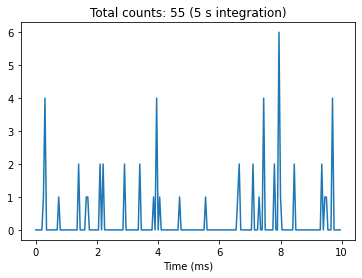

In [308]:
# TEST HISTOGRAM
exhp.reset_detector(detectorOut, 0)
time.sleep(0.1)
intTime = 5
exhp.reset_detector(detectorOut, -0.85)
counts, times = exhp.getHistDataWrapped(hist, intTime = intTime)
# print(counts)
# print(times)
plt.plot(times*1e3, counts)
plt.xlabel('Time (ms)')
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

In [ ]:
## RABI AS A FUNCTION OF PULSE LENGTH
datestring = time.strftime('%Y-%m-%d')
pathData  = f'data/' + datestring + f'/confocal_rabi/run_{rabiCounter}/'
pathPlots = f'plots/' + datestring + f'/confocal_rabi/run_{rabiCounter}/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)
rabiCounter += 1

# Set Up variables
piLengths = swp.sweep_points(0.05, 3, 0.05) # in us
print ("Pi Pulse Lengths - " + str(piLengths))
countFor = 40
switchPreDelay = 5
# period = np.max(piLengths) + 2 * pi2 + 2 * tau + countFor + switchPreDelay

# Ensure that we are growing our pi pulse in both directions
oldPiLength = piLengths[0]

# SNSPD Bias
bias = -0.85
intTime = 10

# Loop over pilengths
for index, piLength in tqdm(enumerate(piLengths)):
        frequency = np.round(wm.readFrequency(), 6)
        print(f'Centre frequency at {frequency} THz')
        swtch.set_up_echo_SNSPD(
                awg,
                pi2 = 0, pi = piLength, tau = 0, period = 0,
                countFor = 10e3,
                switchPreDelay = 0,
                plotting = False
        )
        time.sleep(0.1)
        exhp.reset_detector(detectorOut, bias)
        time.sleep(0.1)

        # Save data and plots
        data, times = exhp.getHistDataWrapped(hist, intTime = 10)
        exhp.reset_detector(detectorOut, 0)
        dataAndTime = np.array([times, data])
        now = datetime.datetime.now()
        timeNow = now.strftime("%Y-%m-%d %H-%M-%S")
        filename =  f"{timeNow}_{wavelength}_nm_piPulse_{piLength}_us"
        np.savetxt(pathData + filename + ".csv", dataAndTime, delimiter = ",")
        fig, ax = plt.subplots()
        ax.plot(times*1e6, data, label = "Total Counts: " + str(sum(data)))
        ax.set_xlabel("Time (us)")
        ax.set_ylabel(f"Counts ({intTime} s integration)")
        ax.set_title(str(np.round(frequency, 6)) +" GHz")
        plt.legend()
        fig.savefig(pathPlots + filename + ".jpg")
        plt.close(fig)

        print(f"{index+1}/{len(piLengths)} Done @ {np.round(piLength, 3)}")

Pi Pulse Lengths - [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1
 2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8
 2.85 2.9  2.95 3.  ]


0it [00:00, ?it/s]

Centre frequency at 197.911987 THz


1it [00:14, 14.43s/it]

1/60 Done @ 0.05
Centre frequency at 197.91185 THz


...

58/60 Done @ 2.9
Centre frequency at 197.911865 THz


59it [14:09, 14.41s/it]

59/60 Done @ 2.95
Centre frequency at 197.911896 THz


60it [14:24, 14.40s/it]

60/60 Done @ 3.0


In [319]:
data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-02-24\confocal_rabi\run_5"
numBins = 100
piLength = []
counts = []

for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    piLength.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts.append(np.sum(data[0:numBins + 1]))
    timeLimit = times[numBins]

    # print(f"{piLength[i]} us Pi Pulse summed over {timeLimit*1e3} ms")

5.0


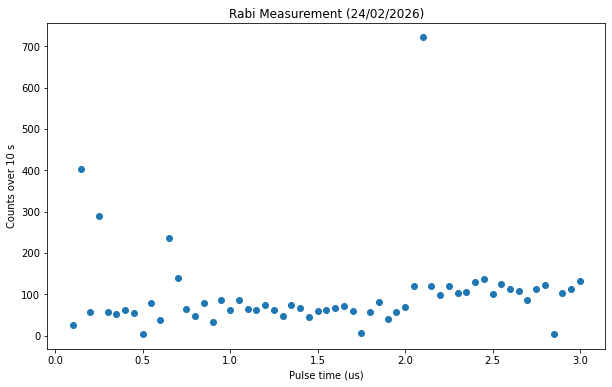

In [323]:
print(timeLimit*1e3)
plt.figure(figsize = (10,6))
plt.xlabel('Pulse time (us)')
plt.ylabel(f'Counts over {intTime} s')
plt.scatter(piLength[1:], np.array(counts)[1:])
plt.title('Rabi Measurement (24/02/2026)')
plt.show()

# 3F Holeburning
**Pseudo-Code**
1. Set up array of [detunings] for $f_1 - \delta$ with $M$ elements. $f_1$ corresponds to the transition of interest.
2. For each $\delta_i$ in [detunings]:

    i. Sequentially excite with $f_0$ and $f_1 - \delta_i$ for $\tau_{exc}$, separated by $\tau_{off}$. Each excitation pulse is followed by an on/off switch to allow detection on the SNSPDs. 
    
    ii. Iterate sequential 2F excitation for N repetitions while integrating #counts from time tagger histogram

3. Repeat for each $\delta_i$, separated by $\tau_{dwell}$ to allow for state relaxation. 

4. Store #counts as a function of [detunings] for bound on homogeneous line.

**Need:**
* Windfreak/rf signal generator to control EOMs
* Also figure out how to connect to magnets for ramp

**Questions**
1. Sites of interest? Ground state? 

In [113]:
import windfreak as wf

### Setup

In [ ]:
# Excite for 1 ms, count for 50 ms with 51 ms dead time (duty cycle = 2)
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = True)
exhp.set_up_echo_SNSPD(awg, 0, 1e3, 1, countFor = 50e3, switchPreDelay = 0, plotting = False)
exhp.set_deadcycles(awg, 2, channels = [1, 2, 3, 4])

### 0 Field

In [ ]:
c = 299792458 #m/s

# Placeholder values
f0 = 10
f1 = 10
t_off = 1
t_dwell = 10

# Measurement parameters
bias = -0.82
intTime = 10
N = 50

# Arrays
ZFieldDetunings = np.arange(0, 10, 100)*1e6 # MHz? Need to get idea of scale
integratedCounts = np.zeros_like(ZFieldDetunings)

# Save path
dateString = time.strftime('%Y-%m-%d')
pathData  = f'data/' + dateString + f'/2Frequency/'
os.makedirs(pathData, exist_ok = True)

In [ ]:
for detuning in ZFieldDetunings:
    subFolderData_f0 = pathData + "/" + f"{str(detuning)}_detuning" + "/"
    subFolderData_f1 = pathData + "/" + f"{str(detuning)}_detuning" + "/"
    os.makedirs(subFolderData_f0, exist_ok = True)
    os.makedirs(subFolderData_f1, exist_ok = True)

    for n in range(N):
        # f0 excitation
        lhzz.set_laser_wavelength(laserIP, c/f0)
        freq = exhp.get_laser_frequency(wm, 10) # THz
        exhp.reset_detector(detectorOut, bias)
        data, times = exhp.getHistDataWrapped(intTime = intTime)      
        dataAndTime = np.array([times, data])
        
        # save f0 data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_f0_" + str(np.round(freq*1e6)) + "_MHz_detuning_" + str(np.round(detuning, 1)) + fr"_MHz_no{n}" 
        np.savetxt(subFolderData_f0 + filename + ".csv", dataAndTime, delimiter = ",")
        
        # off time    
        time.sleep(t_off)
        exhp.reset_detector(detectorOut, 0)
        
        # f1 excitation - or use EOM?
        lhzz.set_laser_wavelength(laserIP, c/(f1 - detuning))
        freq = exhp.get_laser_frequency(wm, 10) # THz
        exhp.reset_detector(detectorOut, bias)
        data, times = exhp.getHistDataWrapped(intTime = intTime)      
        dataAndTime = np.array([times, data])
        
        # save f0 data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_f1_" + str(np.round(freq*1e6)) + "_MHz_detuning_" + str(np.round(detuning, 1)) + fr"_MHz_no{n}" 
        np.savetxt(subFolderData_f1 + filename + ".csv", dataAndTime, delimiter = ",")    

In [ ]:
# Sum counts from f0 and f1 for each detuning


### With Field

In [ ]:
# With field - I'm sensing this will be a longgg run
NZFieldDetunings = np.arange()

# Incoherent Echo Lifetimes
* Randomise phase with incoherent laser or phase modulator
* Use 3 pulse sequence

In [14]:
import drivers.pulse_sequence as beeps

In [82]:
def set_up_3_pulse_echo(pi2, pi, tau, countFor = 10, switchPreDelay = 3, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  

    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, tau, pi2, countFor]
    aomTimings = [pi2, tau, pi, tau, pi2, countFor]
    ttlTimings = [pi2 + tau + pi + tau + pi2, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, tau + pi2 + countFor]
        aomTimings = [pi2 + tau, pi, tau+pi2 + countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau+pi2 + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2+ tau + pi + tau + pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                         color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                 c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                 c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                 c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

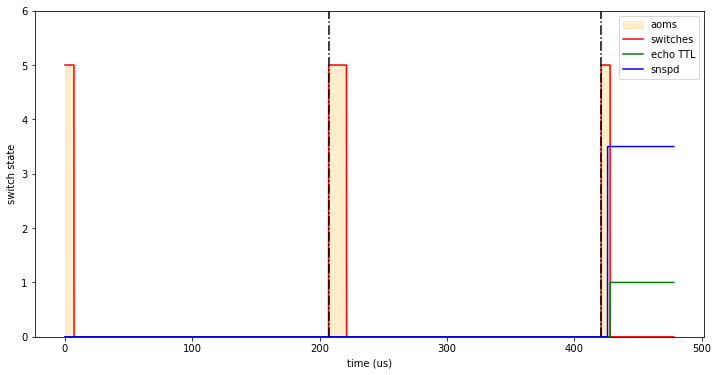

In [106]:
pi2 = 7
tau = 200
pi = 14
countFor = 50
switchPreDelay = 2

# tau is defined wrt. start of each pulse
set_up_3_pulse_echo(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000, 
                    plotting = True, verbose = False, pi2Off = False, piOff = False)
plt.vlines([pi2 + tau, pi2 + tau + pi + tau], 0, 6, 
linestyles = '-.', colors = 'k')
plt.ylim([0, 6])
plt.show()